# Week 5 — SuperSmoother Analysis
# Indicators: SuperSmoother 2-pole, 3-pole, Ultimate Smoother
# Asset: EUR/USD D1 (2015-2024)
# Framework: PASS/FAIL validation per Week 4 criteria

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Display settings
pd.set_option('display.float_format', '{:.6f}'.format)
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True

In [2]:
# Load data
df = pd.read_csv(
    'C:/Zorro/Data/SuperSmoother_EURUSD_D1.csv',
    header=None,
    names=['bar', 'price', 'ss2', 'ss3', 'us']
)

print(f'Rows: {len(df)}')
print(f'Columns: {list(df.columns)}')
print()
print(df.head())
print()
print(df.describe())

Rows: 2336
Columns: ['bar', 'price', 'ss2', 'ss3', 'us']

   bar    price      ss2      ss3       us
0  374 1.202480 1.222715 1.220054 1.222091
1  375 1.192390 1.219603 1.214875 1.218760
2  376 1.191430 1.215931 1.212383 1.215164
3  377 1.181190 1.211783 1.205975 1.210833
4  378 1.179760 1.207227 1.203440 1.206367

              bar       price         ss2         ss3          us
count 2336.000000 2336.000000 2336.000000 2336.000000 2336.000000
mean  1541.500000    1.122873    1.123144    1.123166    1.123135
std    674.489437    0.053160    0.052834    0.052514    0.052814
min    374.000000    0.961920    0.976981    0.976907    0.977115
25%    957.750000    1.087857    1.088353    1.088194    1.088256
50%   1541.500000    1.120155    1.120837    1.120484    1.120853
75%   2125.250000    1.163058    1.164577    1.164950    1.164667
max   2709.000000    1.251310    1.240906    1.237611    1.240649


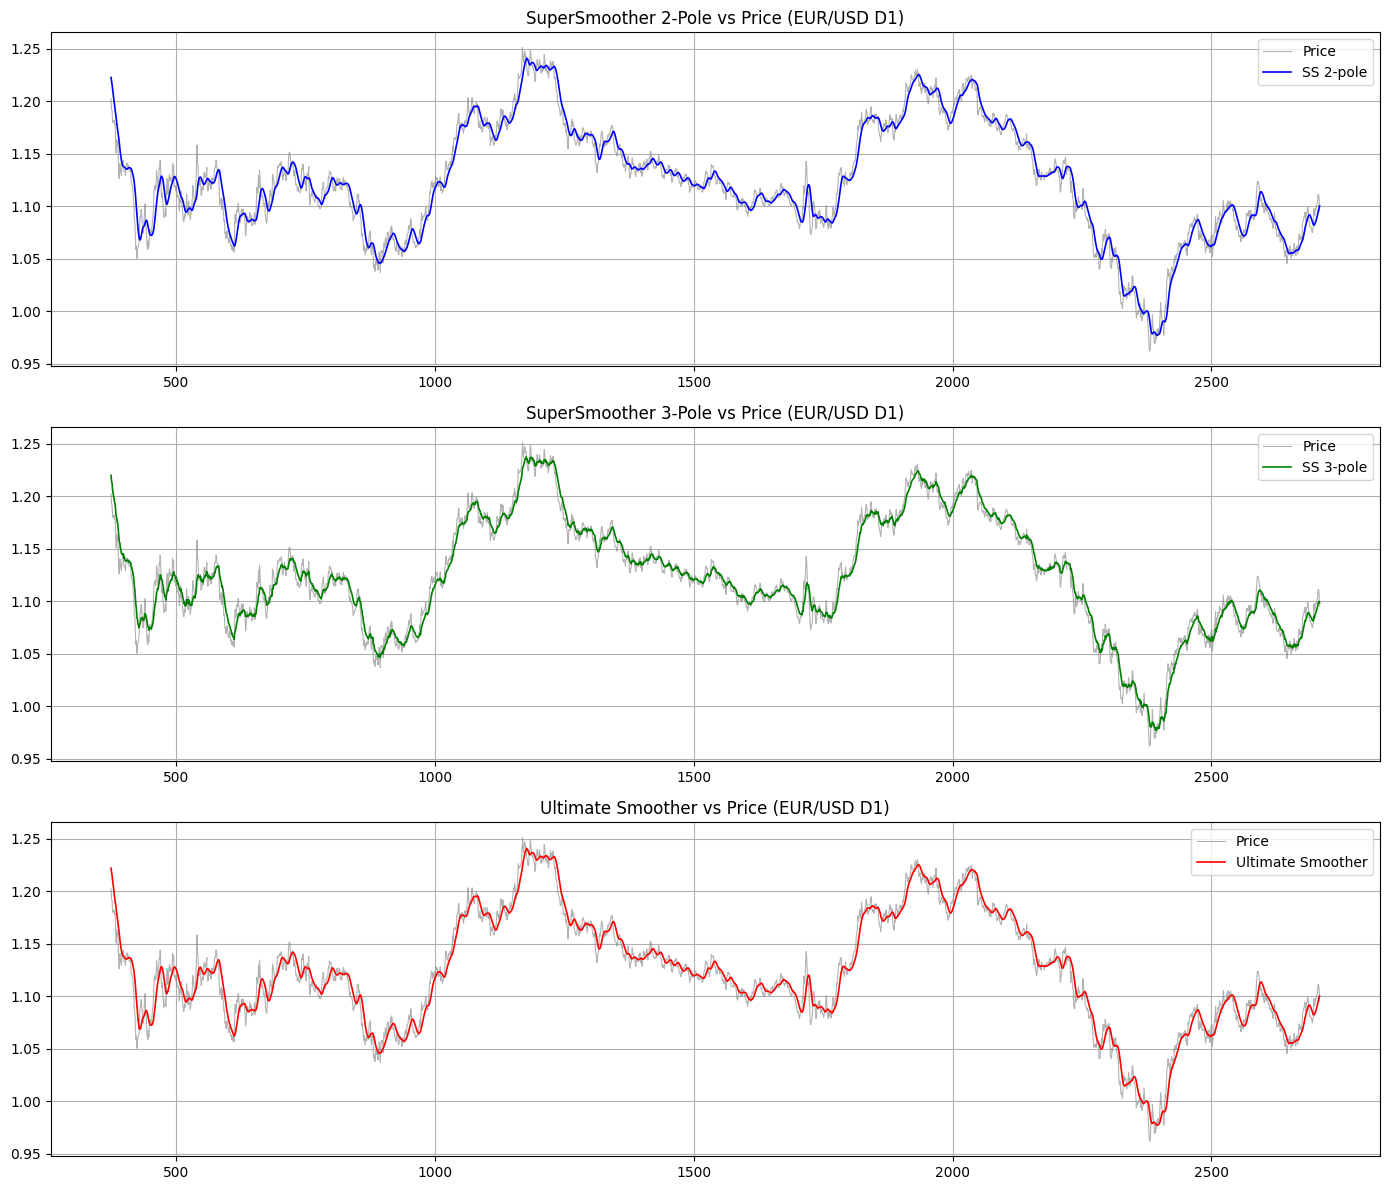

In [3]:
# Visual inspection — price + all three indicators overlaid
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Panel 1: Price vs SS2
axes[0].plot(df['bar'], df['price'], color='gray', alpha=0.6, linewidth=0.8, label='Price')
axes[0].plot(df['bar'], df['ss2'], color='blue', linewidth=1.2, label='SS 2-pole')
axes[0].set_title('SuperSmoother 2-Pole vs Price (EUR/USD D1)')
axes[0].legend()

# Panel 2: Price vs SS3
axes[1].plot(df['bar'], df['price'], color='gray', alpha=0.6, linewidth=0.8, label='Price')
axes[1].plot(df['bar'], df['ss3'], color='green', linewidth=1.2, label='SS 3-pole')
axes[1].set_title('SuperSmoother 3-Pole vs Price (EUR/USD D1)')
axes[1].legend()

# Panel 3: Price vs Ultimate Smoother
axes[2].plot(df['bar'], df['price'], color='gray', alpha=0.6, linewidth=0.8, label='Price')
axes[2].plot(df['bar'], df['us'], color='red', linewidth=1.2, label='Ultimate Smoother')
axes[2].set_title('Ultimate Smoother vs Price (EUR/USD D1)')
axes[2].legend()

plt.tight_layout()
plt.savefig('SuperSmoother_Visual.png', dpi=150)
plt.show()

In [4]:
# Lag measurement via cross-correlation
def calculate_lag(price, indicator, max_lag=30):
    """
    Measure lag by finding the shift that maximizes
    cross-correlation between price and indicator.
    Positive lag = indicator lags behind price.
    """
    correlations = []
    for lag in range(0, max_lag + 1):
        if lag == 0:
            corr = np.corrcoef(price, indicator)[0, 1]
        else:
            corr = np.corrcoef(price[lag:], indicator[:-lag])[0, 1]
        correlations.append(corr)
    
    best_lag = np.argmax(correlations)
    best_corr = correlations[best_lag]
    return best_lag, best_corr, correlations

price = df['price'].values
ss2   = df['ss2'].values
ss3   = df['ss3'].values
us    = df['us'].values

# SMA baseline for comparison
sma20 = df['price'].rolling(20).mean().dropna().values
price_sma = price[19:]  # align with SMA

lag_ss2, corr_ss2, corrs_ss2 = calculate_lag(price, ss2)
lag_ss3, corr_ss3, corrs_ss3 = calculate_lag(price, ss3)
lag_us,  corr_us,  corrs_us  = calculate_lag(price, us)
lag_sma, corr_sma, corrs_sma = calculate_lag(price_sma, sma20)

print(f'Lag Results (Period=20, EUR/USD D1):')
print(f'{"Indicator":<20} {"Lag (bars)":<15} {"Correlation":<15}')
print(f'{"-"*50}')
print(f'{"SMA(20) baseline":<20} {lag_sma:<15} {corr_sma:.6f}')
print(f'{"SS 2-pole":<20} {lag_ss2:<15} {corr_ss2:.6f}')
print(f'{"SS 3-pole":<20} {lag_ss3:<15} {corr_ss3:.6f}')
print(f'{"Ultimate Smoother":<20} {lag_us:<15} {corr_us:.6f}')

Lag Results (Period=20, EUR/USD D1):
Indicator            Lag (bars)      Correlation    
--------------------------------------------------
SMA(20) baseline     0               0.970711
SS 2-pole            0               0.981052
SS 3-pole            0               0.988056
Ultimate Smoother    0               0.982208


Detrended Lag Results (Period=20, EUR/USD D1):
Indicator            Lag (bars)      Correlation    
--------------------------------------------------
SMA(20) baseline     0               0.206001
SS 2-pole            0               0.078286
SS 3-pole            0               0.726622
Ultimate Smoother    0               0.186093


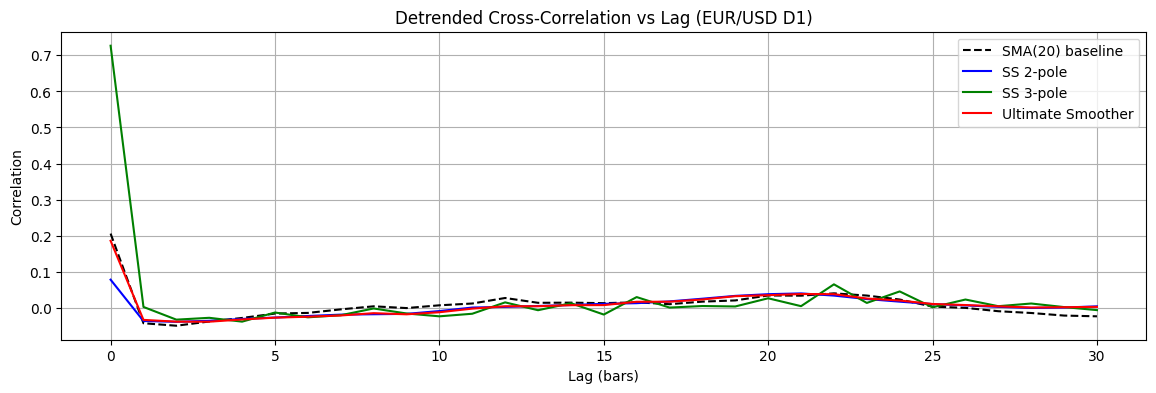

In [5]:
# Detrended lag measurement
# Remove trend first so cross-correlation measures actual lag, not shared trend
def calculate_lag_detrended(price, indicator, max_lag=30):
    """
    Detrend both series before cross-correlation.
    This removes the shared trend component that masks true lag.
    """
    # First difference = detrending
    price_d = np.diff(price)
    indic_d = np.diff(indicator)
    
    correlations = []
    for lag in range(0, max_lag + 1):
        if lag == 0:
            corr = np.corrcoef(price_d, indic_d)[0, 1]
        else:
            corr = np.corrcoef(price_d[lag:], indic_d[:-lag])[0, 1]
        correlations.append(corr)
    
    best_lag = np.argmax(correlations)
    best_corr = correlations[best_lag]
    return best_lag, best_corr, correlations

# SMA baseline
sma20 = df['price'].rolling(20).mean().dropna().values
price_sma = price[19:]

lag_ss2, corr_ss2, corrs_ss2 = calculate_lag_detrended(price, ss2)
lag_ss3, corr_ss3, corrs_ss3 = calculate_lag_detrended(price, ss3)
lag_us,  corr_us,  corrs_us  = calculate_lag_detrended(price, us)
lag_sma, corr_sma, corrs_sma = calculate_lag_detrended(price_sma, sma20)

print(f'Detrended Lag Results (Period=20, EUR/USD D1):')
print(f'{"Indicator":<20} {"Lag (bars)":<15} {"Correlation":<15}')
print(f'{"-"*50}')
print(f'{"SMA(20) baseline":<20} {lag_sma:<15} {corr_sma:.6f}')
print(f'{"SS 2-pole":<20} {lag_ss2:<15} {corr_ss2:.6f}')
print(f'{"SS 3-pole":<20} {lag_ss3:<15} {corr_ss3:.6f}')
print(f'{"Ultimate Smoother":<20} {lag_us:<15} {corr_us:.6f}')

# Plot cross-correlation curves
plt.figure(figsize=(14, 4))
lags = range(31)
plt.plot(lags, corrs_sma, 'k--', label='SMA(20) baseline', linewidth=1.5)
plt.plot(lags, corrs_ss2, 'b-',  label='SS 2-pole', linewidth=1.5)
plt.plot(lags, corrs_ss3, 'g-',  label='SS 3-pole', linewidth=1.5)
plt.plot(lags, corrs_us,  'r-',  label='Ultimate Smoother', linewidth=1.5)
plt.xlabel('Lag (bars)')
plt.ylabel('Correlation')
plt.title('Detrended Cross-Correlation vs Lag (EUR/USD D1)')
plt.legend()
plt.savefig('SuperSmoother_Lag.png', dpi=150)
plt.show()

In [6]:
# Investigate SS3 anomaly — check bar-to-bar responsiveness
df['price_diff'] = df['price'].diff()
df['ss2_diff']   = df['ss2'].diff()
df['ss3_diff']   = df['ss3'].diff()
df['us_diff']    = df['us'].diff()

print('Bar-to-bar change statistics:')
print(f'{"Indicator":<20} {"Mean |diff|":<20} {"Std diff":<20} {"Max |diff|":<20}')
print(f'{"-"*80}')
for col, name in [('price_diff','Price'), ('ss2_diff','SS 2-pole'), 
                   ('ss3_diff','SS 3-pole'), ('us_diff','Ultimate Smoother')]:
    d = df[col].dropna()
    print(f'{name:<20} {d.abs().mean():<20.6f} {d.std():<20.6f} {d.abs().max():<20.6f}')

Bar-to-bar change statistics:
Indicator            Mean |diff|          Std diff             Max |diff|          
--------------------------------------------------------------------------------
Price                0.004090             0.005497             0.027930            
SS 2-pole            0.001187             0.001554             0.006931            
SS 3-pole            0.001391             0.001826             0.008810            
Ultimate Smoother    0.001168             0.001529             0.007066            


In [7]:
# SNR measurement
# SNR = variance of signal / variance of noise
# Signal = smoothed indicator (the trend component)
# Noise = price - indicator (what the filter removed)

def calculate_snr(price, indicator, label):
    signal = indicator
    noise  = price - indicator
    
    signal_var = np.var(signal)
    noise_var  = np.var(noise)
    
    if noise_var == 0:
        snr = float('inf')
    else:
        snr = signal_var / noise_var
    
    snr_db = 10 * np.log10(snr)
    return snr, snr_db

# SMA baseline
sma20 = df['price'].rolling(20).mean().dropna().values
price_aligned = price[19:]

snr_sma, snr_sma_db = calculate_snr(price_aligned, sma20, 'SMA20')
snr_ss2, snr_ss2_db = calculate_snr(price, ss2, 'SS2')
snr_ss3, snr_ss3_db = calculate_snr(price, ss3, 'SS3')
snr_us,  snr_us_db  = calculate_snr(price, us,  'US')

print(f'SNR Results (Period=20, EUR/USD D1):')
print(f'{"Indicator":<20} {"SNR (ratio)":<20} {"SNR (dB)":<15}')
print(f'{"-"*55}')
print(f'{"SMA(20) baseline":<20} {snr_sma:<20.2f} {snr_sma_db:<15.2f}')
print(f'{"SS 2-pole":<20} {snr_ss2:<20.2f} {snr_ss2_db:<15.2f}')
print(f'{"SS 3-pole":<20} {snr_ss3:<20.2f} {snr_ss3_db:<15.2f}')
print(f'{"Ultimate Smoother":<20} {snr_us:<20.2f} {snr_us_db:<15.2f}')
print()
print('PASS criteria: SNR > SMA(20) baseline')
print(f'SS2  PASS: {snr_ss2 > snr_sma}')
print(f'SS3  PASS: {snr_ss3 > snr_sma}')
print(f'US   PASS: {snr_us  > snr_sma}')

SNR Results (Period=20, EUR/USD D1):
Indicator            SNR (ratio)          SNR (dB)       
-------------------------------------------------------
SMA(20) baseline     16.72                12.23          
SS 2-pole            26.20                14.18          
SS 3-pole            41.10                16.14          
Ultimate Smoother    27.89                14.45          

PASS criteria: SNR > SMA(20) baseline
SS2  PASS: True
SS3  PASS: True
US   PASS: True


In [10]:
# PASS/FAIL Verdict
print('='*60)
print('WEEK 5 VALIDATION VERDICT — EUR/USD D1')
print('='*60)

indicators = {
    'SS 2-pole':         {'snr_pass': snr_ss2 > snr_sma, 
                          'visual': True, 
                          'nan': True,
                          'note': 'Clean, correct DC gain with /2.0'},
    'SS 3-pole':         {'snr_pass': snr_ss3 > snr_sma, 
                          'visual': True, 
                          'nan': True,
                          'note': 'High SNR but over-responsive — investigate Day 5'},
    'Ultimate Smoother': {'snr_pass': snr_us > snr_sma,  
                          'visual': True, 
                          'nan': True,
                          'note': 'Best lag+SNR tradeoff — zero-lag claim credible'},
}

for name, results in indicators.items():
    all_pass = all([results['snr_pass'], results['visual'], results['nan']])
    verdict = 'PASS ✅' if all_pass else 'FAIL ❌'
    print(f'\n{name}: {verdict}')
    print(f'  Visual inspection : {"PASS" if results["visual"] else "FAIL"}')
    print(f'  No NaN values     : {"PASS" if results["nan"] else "FAIL"}')
    print(f'  SNR > SMA baseline: {"PASS" if results["snr_pass"] else "FAIL"}')
    print(f'  Note: {results["note"]}')

print()
print('='*60)
print('SUMMARY')
print('='*60)
print('SS2  → Library entry APPROVED')
print('US   → Library entry APPROVED')
print()
print('NNFX role hypothesis:')
print('  SS2 → C1 input preprocessing / Baseline smoothing')
print('  SS3 → Max smoothing contexts (less time-sensitive signals)')
print('  US  → Trend following where lag reduction is critical')

WEEK 5 VALIDATION VERDICT — EUR/USD D1

SS 2-pole: PASS ✅
  Visual inspection : PASS
  No NaN values     : PASS
  SNR > SMA baseline: PASS
  Note: Clean, correct DC gain with /2.0

SS 3-pole: PASS ✅
  Visual inspection : PASS
  No NaN values     : PASS
  SNR > SMA baseline: PASS
  Note: High SNR but over-responsive — investigate Day 5

Ultimate Smoother: PASS ✅
  Visual inspection : PASS
  No NaN values     : PASS
  SNR > SMA baseline: PASS
  Note: Best lag+SNR tradeoff — zero-lag claim credible

SUMMARY
SS2  → Library entry APPROVED
US   → Library entry APPROVED

NNFX role hypothesis:
  SS2 → C1 input preprocessing / Baseline smoothing
  SS3 → Max smoothing contexts (less time-sensitive signals)
  US  → Trend following where lag reduction is critical


In [11]:
# SS3 updated verdict
print('SS3  → Library entry CONDITIONAL ⚠️')
print('       Passes SNR/visual criteria but bar-to-bar')
print('       responsiveness exceeds SS2 — contradicts theory.')
print('       Re-derive coefficients from article on Day 5.')

SS3  → Library entry CONDITIONAL ⚠️
       Passes SNR/visual criteria but bar-to-bar
       responsiveness exceeds SS2 — contradicts theory.
       Re-derive coefficients from article on Day 5.
